# Combined indicator

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [173]:
import ocha_stratus as stratus
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut

from src.constants import *

In [4]:
blob_name = f"{PROJECT_PREFIX}/processed/iri_cerf_stats.parquet"
df_stats_iri = stratus.load_parquet_from_blob(blob_name)

In [5]:
df_stats_iri

,year,Jan,Feb,Mar,Apr,May,Jun,Humanitarian Bad Years (rank),EM-DAT Bad Years,CHIRPS Precip JAS (mm),emdat_float,Amount in US$
0,1991,29.4,31.0,31.9,32.6,30.5,42.3,16.0,None,62.1,0.0,NaN
1,1992,30.0,41.7,38.5,46.7,39.3,40.1,16.0,None,53.4,0.0,NaN
2,1993,32.6,37.6,33.9,37.2,38.3,47.5,16.0,None,70.4,0.0,NaN
3,1994,32.3,32.8,35.3,42.0,43.8,39.4,16.0,None,80.7,0.0,NaN
4,1995,33.7,31.6,24.5,30.8,31.3,27.2,16.0,None,91.1,0.0,NaN
5,1996,37.6,39.3,34.1,43.2,31.6,33.0,16.0,None,60.7,0.0,NaN
6,1997,34.2,39.6,42.4,28.9,36.1,41.3,16.0,None,71.2,0.0,NaN
7,1998,32.8,26.8,33.0,25.8,30.6,27.5,16.0,None,85.0,0.0,NaN
8,1999,36.3,31.3,35.8,40.3,27.5,25.7,30.0,None,99.1,0.0,NaN
9,2000,36.1,32.9,32.5,27.7,35.4,28.0,16.0,None,76.7,0.0,NaN


In [6]:
blob_name = (
    f"{PROJECT_PREFIX}/processed/chirps/chirps_dek_season_cumul.parquet"
)
df_chirps_raw = stratus.load_parquet_from_blob(blob_name)

In [8]:
blob_name = f"{PROJECT_PREFIX}/processed/asi/mrt_asi_dekadal.parquet"
df_asi_raw = stratus.load_parquet_from_blob(blob_name)

<Axes: xlabel='asi_all'>

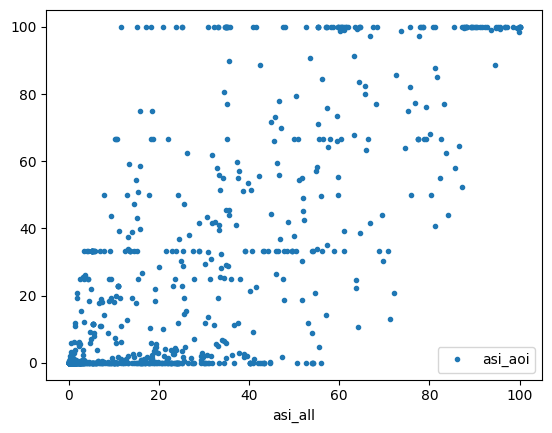

In [132]:
df_asi_raw.plot(x="asi_all", y="asi_aoi", linewidth=0, marker=".")

In [16]:
df_dek = df_chirps_raw.merge(df_asi_raw)
df_dek = df_dek.drop(columns=["Year", "Month", "Dekad"])

In [317]:
min_year, max_year = 1991, 2024
total_years = max_year - min_year + 1

In [320]:
df_dek_limit_years = df_dek[
    df_dek["year"].isin(range(min_year, max_year + 1))
].copy()

In [90]:
geos = ["all", "aoi"]
ind_cols = [f"rfh_{x}_cumul" for x in geos] + [f"asi_{x}" for x in geos]

In [91]:
flip_cols = [x for x in cols if "rfh" in x]

In [92]:
flip_cols

['rfh_all_cumul', 'rfh_aoi_cumul']

In [93]:
df_dek_limit_years

,date,rfh_all,rfh_aoi,year,rfh_all_cumul,rfh_aoi_cumul,dekad,dekad_overall,asi_all,asi_aoi,rfh_all_cumul_norm,rfh_aoi_cumul_norm,asi_all_norm,asi_aoi_norm
63,1991-07-01,5.617332,18.406073,1991,5.617332,18.406073,1,19,83.679592,62.572163,-0.826452,0.153217,1.875680,2.329480
64,1991-07-11,3.912060,15.553448,1991,9.529392,33.959520,2,20,65.837166,63.452788,0.124934,0.499618,1.893480,2.444311
65,1991-07-21,6.490611,18.647058,1991,16.020003,52.606578,3,21,37.873673,57.112503,0.402443,0.814976,1.463873,2.091336
66,1991-08-01,4.910419,17.289690,1991,20.930421,69.896268,1,22,37.662681,54.866114,1.025277,1.060655,1.303310,2.055459
67,1991-08-11,10.776464,49.020874,1991,31.706886,118.917142,2,23,42.288469,55.729734,0.840663,0.575606,1.668988,2.042586
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
364,2024-08-11,12.699847,33.545225,2024,41.301433,149.721697,2,23,0.713157,0.000000,-0.483822,-0.310373,-0.753632,-0.472681
365,2024-08-21,10.283822,42.637570,2024,51.585255,192.359267,3,24,1.118828,0.642633,-0.138522,-0.350685,-0.648340,-0.436474
366,2024-09-01,13.865711,45.931057,2024,65.450967,238.290323,1,25,1.664252,0.107234,-0.461073,-0.661171,-0.559735,-0.464472
367,2024-09-11,15.108276,49.688804,2024,80.559243,287.979128,2,26,1.308534,0.000000,-0.924466,-1.083690,-0.594801,-0.478383


In [117]:
for col in ind_cols:
    flip = -1 if col in flip_cols else 1
    df_dek_limit_years[f"{col}_norm"] = flip * df_dek_limit_years.groupby(
        "dekad_overall"
    )[col].transform(lambda x: (x - x.mean()) / x.std())

In [119]:
df_dek_limit_years.corr()

,date,rfh_all,rfh_aoi,year,rfh_all_cumul,rfh_aoi_cumul,dekad,dekad_overall,asi_all,asi_aoi,rfh_all_cumul_norm,rfh_aoi_cumul_norm,asi_all_norm,asi_aoi_norm
date,1.000000,0.086122,0.132099,9.999725e-01,0.059945,0.104982,2.278510e-03,7.421440e-03,-0.328757,-0.277916,-1.685447e-01,-2.491925e-01,-3.368696e-01,-2.790169e-01
rfh_all,0.086122,1.000000,0.800291,8.386495e-02,0.429513,0.442330,1.650649e-01,3.054994e-01,-0.282078,-0.190221,-4.990802e-01,-3.889189e-01,-2.079783e-01,-1.832537e-01
rfh_aoi,0.132099,0.800291,1.000000,1.314787e-01,0.199752,0.276366,1.361335e-01,8.463333e-02,-0.227431,-0.190331,-5.003025e-01,-5.452444e-01,-1.917200e-01,-1.884431e-01
year,0.999972,0.083865,0.131479,1.000000e+00,0.052935,0.098232,7.769211e-16,2.093679e-15,-0.327596,-0.277719,-1.685509e-01,-2.491920e-01,-3.368710e-01,-2.790101e-01
rfh_all_cumul,0.059945,0.429513,0.199752,5.293500e-02,1.000000,0.976068,2.780395e-01,9.445894e-01,-0.274770,-0.159723,-2.783150e-01,-2.416767e-01,-1.539543e-01,-1.370059e-01
rfh_aoi_cumul,0.104982,0.442330,0.276366,9.823198e-02,0.976068,1.000000,2.757936e-01,9.092558e-01,-0.292225,-0.214396,-3.286089e-01,-3.784431e-01,-1.751660e-01,-1.924631e-01
dekad,0.002279,0.165065,0.136133,7.769211e-16,0.278040,0.275794,1.000000e+00,3.162278e-01,-0.109300,-0.002207,-3.141731e-16,-6.308613e-17,-1.701012e-16,-9.183375e-17
dekad_overall,0.007421,0.305499,0.084633,2.093679e-15,0.944589,0.909256,3.162278e-01,1.000000e+00,-0.157247,-0.025600,-4.392589e-16,-1.750385e-16,-5.522178e-16,-4.670612e-16
asi_all,-0.328757,-0.282078,-0.227431,-3.275956e-01,-0.274770,-0.292225,-1.092997e-01,-1.572471e-01,1.000000,0.736586,4.421517e-01,3.546706e-01,9.535326e-01,7.338068e-01
asi_aoi,-0.277916,-0.190221,-0.190331,-2.777192e-01,-0.159723,-0.214396,-2.206927e-03,-2.559962e-02,0.736586,1.000000,4.600861e-01,4.667060e-01,7.639950e-01,9.993235e-01


In [95]:
df_dek_limit_years.groupby("dekad_overall")["asi_all_norm"].mean()

dekad_overall
19    1.093896e-16
20   -7.510332e-17
21   -3.265362e-18
22   -3.918434e-17
23   -8.816477e-17
24    6.530724e-18
25    1.306145e-17
26    9.143013e-17
27   -9.796086e-18
Name: asi_all_norm, dtype: float64

In [96]:
df_dek_limit_years

,date,rfh_all,rfh_aoi,year,rfh_all_cumul,rfh_aoi_cumul,dekad,dekad_overall,asi_all,asi_aoi,rfh_all_cumul_norm,rfh_aoi_cumul_norm,asi_all_norm,asi_aoi_norm
63,1991-07-01,5.617332,18.406073,1991,5.617332,18.406073,1,19,83.679592,62.572163,-0.826452,0.153217,1.875680,2.329480
64,1991-07-11,3.912060,15.553448,1991,9.529392,33.959520,2,20,65.837166,63.452788,0.124934,0.499618,1.893480,2.444311
65,1991-07-21,6.490611,18.647058,1991,16.020003,52.606578,3,21,37.873673,57.112503,0.402443,0.814976,1.463873,2.091336
66,1991-08-01,4.910419,17.289690,1991,20.930421,69.896268,1,22,37.662681,54.866114,1.025277,1.060655,1.303310,2.055459
67,1991-08-11,10.776464,49.020874,1991,31.706886,118.917142,2,23,42.288469,55.729734,0.840663,0.575606,1.668988,2.042586
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
364,2024-08-11,12.699847,33.545225,2024,41.301433,149.721697,2,23,0.713157,0.000000,-0.483822,-0.310373,-0.753632,-0.472681
365,2024-08-21,10.283822,42.637570,2024,51.585255,192.359267,3,24,1.118828,0.642633,-0.138522,-0.350685,-0.648340,-0.436474
366,2024-09-01,13.865711,45.931057,2024,65.450967,238.290323,1,25,1.664252,0.107234,-0.461073,-0.661171,-0.559735,-0.464472
367,2024-09-11,15.108276,49.688804,2024,80.559243,287.979128,2,26,1.308534,0.000000,-0.924466,-1.083690,-0.594801,-0.478383


In [97]:
df_stats_iri.columns

Index(['year', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
       'Humanitarian Bad Years (rank)', 'EM-DAT Bad Years',
       'CHIRPS Precip JAS (mm)', 'emdat_float', 'Amount in US$',
       'hum_bad_flipped', 'hum_bad_aligned', 'cerf_aligned', 'hum_bad_norm',
       'hum_bad', 'hum_bad_aligned_norm', 'cerf_aligned_norm'],
      dtype='object')

In [98]:
df_stats_iri["hum_bad"] = -df_stats_iri["Humanitarian Bad Years (rank)"]
df_stats_iri["cerf_aligned"] = df_stats_iri["Amount in US$"]

In [99]:
for col in ["hum_bad_aligned", "cerf_aligned"]:
    df_stats_iri[f"{col}_norm"] = (
        df_stats_iri[col] - df_stats_iri[col].mean()
    ) / df_stats_iri[col].std()

In [203]:
rp_overall_target = 4
n_years_overall_target = int((max_year - min_year + 1 + 1) / rp_overall_target)

In [204]:
n_years_overall_target

8

In [209]:
max_badyear_target = df_stats_iri.sort_values(
    "Humanitarian Bad Years (rank)"
).iloc[n_years_overall_target - 1]["Humanitarian Bad Years (rank)"]

In [213]:
df_stats_iri["target"] = (
    df_stats_iri["Humanitarian Bad Years (rank)"] <= max_badyear_target
)

In [216]:
df_stats_iri[["year", "Amount in US$", "target"]]

,year,Amount in US$,target
0,1991,NaN,False
1,1992,NaN,False
2,1993,NaN,False
3,1994,NaN,False
4,1995,NaN,False
5,1996,NaN,False
6,1997,NaN,False
7,1998,NaN,False
8,1999,NaN,False
9,2000,NaN,False


In [251]:
df_dek_compare = df_dek_limit_years.merge(df_stats_iri)

In [252]:
target_col = "hum_bad_aligned_norm"

for dekad, group in df_dek_compare.groupby("dekad_overall"):
    X = group[ind_norm_all_cols]
    # X = sm.add_constant(X)  # adds intercept
    y = group[target_col]

    model = sm.OLS(y, X).fit()
    print(model.summary())  # nicely formatted regression output

    # Predicted values:
    y_pred = model.predict(X)

    df_dek_compare.loc[group.index, f"{target_col}_reg"] = y_pred

                                  OLS Regression Results                                 
Dep. Variable:     hum_bad_aligned_norm   R-squared (uncentered):                   0.189
Model:                              OLS   Adj. R-squared (uncentered):              0.138
Method:                   Least Squares   F-statistic:                              3.732
Date:                  Wed, 04 Feb 2026   Prob (F-statistic):                      0.0349
Time:                          15:24:16   Log-Likelihood:                         -44.172
No. Observations:                    34   AIC:                                      92.34
Df Residuals:                        32   BIC:                                      95.40
Df Model:                             2                                                  
Covariance Type:              nonrobust                                                  
                         coef    std err          t      P>|t|      [0.025      0.975]
-------------

In [253]:
X = df_dek_compare[ind_norm_all_cols]
# X = sm.add_constant(X)  # adds intercept
y = df_dek_compare[target_col]

model = sm.OLS(y, X).fit()
print(model.summary())  # nicely formatted regression output

# Predicted values:
y_pred = model.predict(X)

df_dek_compare[f"{target_col}_single_reg"] = y_pred

                                  OLS Regression Results                                 
Dep. Variable:     hum_bad_aligned_norm   R-squared (uncentered):                   0.329
Model:                              OLS   Adj. R-squared (uncentered):              0.324
Method:                   Least Squares   F-statistic:                              74.49
Date:                  Wed, 04 Feb 2026   Prob (F-statistic):                    4.72e-27
Time:                          15:24:17   Log-Likelihood:                         -368.61
No. Observations:                   306   AIC:                                      741.2
Df Residuals:                       304   BIC:                                      748.7
Df Model:                             2                                                  
Covariance Type:              nonrobust                                                  
                         coef    std err          t      P>|t|      [0.025      0.975]
-------------

In [254]:
df_corr = (
    df_dek_compare.groupby("dekad_overall")
    .corr(numeric_only=True)
    .reset_index()
    .rename(columns={"level_1": "variable"})
)

In [255]:
ind_norm_cols = [f"{x}_norm" for x in ind_cols]

In [256]:
ind_norm_all_cols

['rfh_all_cumul_norm', 'asi_all_norm']

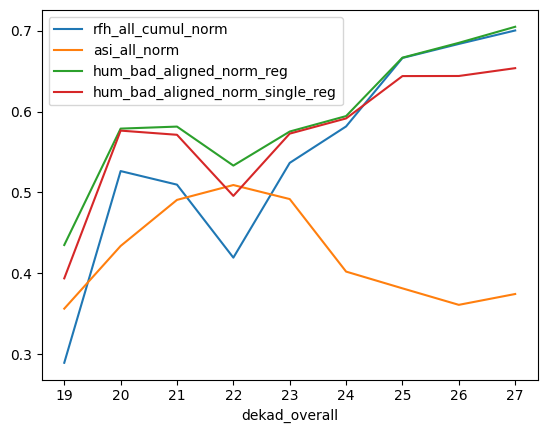

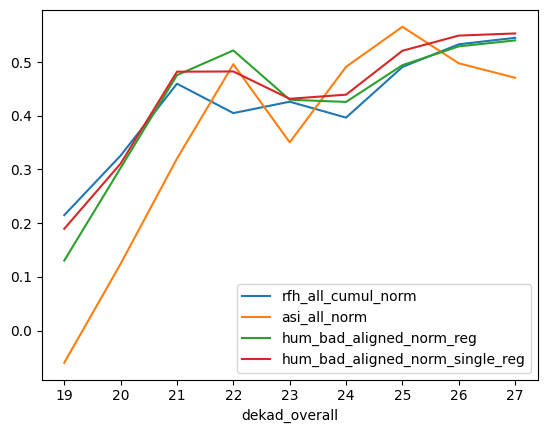

In [257]:
for target_col in ["hum_bad_aligned_norm", "cerf_aligned_norm"]:
    df_corr[df_corr["variable"] == target_col].set_index("dekad_overall")[
        ind_norm_all_cols
        + ["hum_bad_aligned_norm_reg", "hum_bad_aligned_norm_single_reg"]
    ].plot()

In [258]:
ind_norm_all_cols = [x for x in ind_norm_cols if "all" in x]

In [259]:
ind_norm_all_cols

['rfh_all_cumul_norm', 'asi_all_norm']

In [260]:
df_dek_compare

,date,rfh_all,rfh_aoi,year,rfh_all_cumul,rfh_aoi_cumul,dekad,dekad_overall,asi_all,asi_aoi,...,hum_bad_flipped,hum_bad_aligned,cerf_aligned,hum_bad_norm,hum_bad,hum_bad_aligned_norm,cerf_aligned_norm,target,hum_bad_aligned_norm_reg,hum_bad_aligned_norm_single_reg
0,1991-07-01,5.617332,18.406073,1991,5.617332,18.406073,1,19,83.679592,62.572163,...,-16.0,-16.0,NaN,-16.0,-16.0,0.191937,NaN,False,0.405680,0.010647
1,1991-07-11,3.912060,15.553448,1991,9.529392,33.959520,2,20,65.837166,63.452788,...,-16.0,-16.0,NaN,-16.0,-16.0,0.191937,NaN,False,0.551452,0.438665
2,1991-07-21,6.490611,18.647058,1991,16.020003,52.606578,3,21,37.873673,57.112503,...,-16.0,-16.0,NaN,-16.0,-16.0,0.191937,NaN,False,0.610667,0.475580
3,1991-08-01,4.910419,17.289690,1991,20.930421,69.896268,1,22,37.662681,54.866114,...,-16.0,-16.0,NaN,-16.0,-16.0,0.191937,NaN,False,0.718406,0.720957
4,1991-08-11,10.776464,49.020874,1991,31.706886,118.917142,2,23,42.288469,55.729734,...,-16.0,-16.0,NaN,-16.0,-16.0,0.191937,NaN,False,0.753904,0.712554
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
301,2024-08-11,12.699847,33.545225,2024,41.301433,149.721697,2,23,0.713157,0.000000,...,-30.0,-30.0,0.0,-30.0,-30.0,-1.469192,-0.591314,False,-0.379685,-0.368247
302,2024-08-21,10.283822,42.637570,2024,51.585255,192.359267,3,24,1.118828,0.642633,...,-30.0,-30.0,0.0,-30.0,-30.0,-1.469192,-0.591314,False,-0.162938,-0.192913
303,2024-09-01,13.865711,45.931057,2024,65.450967,238.290323,1,25,1.664252,0.107234,...,-30.0,-30.0,0.0,-30.0,-30.0,-1.469192,-0.591314,False,-0.315539,-0.318885
304,2024-09-11,15.108276,49.688804,2024,80.559243,287.979128,2,26,1.308534,0.000000,...,-30.0,-30.0,0.0,-30.0,-30.0,-1.469192,-0.591314,False,-0.628807,-0.532699


In [267]:
target_col = "hum_bad_aligned_norm"
pred_col = f"{target_col}_reg_loocv"
df_dek_compare[pred_col] = np.nan

loo = LeaveOneOut()

for dekad, group in df_dek_compare.groupby("dekad_overall"):
    X = group[ind_norm_all_cols].values
    y = group[target_col].values

    preds = np.zeros(len(group))

    for train_idx, test_idx in loo.split(X):
        model = LinearRegression()
        model.fit(X[train_idx], y[train_idx])
        preds[test_idx] = model.predict(X[test_idx])

    df_dek_compare.loc[group.index, pred_col] = preds

In [268]:
df_dek_compare

,date,rfh_all,rfh_aoi,year,rfh_all_cumul,rfh_aoi_cumul,dekad,dekad_overall,asi_all,asi_aoi,...,cerf_aligned,hum_bad_norm,hum_bad,hum_bad_aligned_norm,cerf_aligned_norm,target,hum_bad_aligned_norm_reg,hum_bad_aligned_norm_single_reg,cerf_aligned_norm_reg_loocv,hum_bad_aligned_norm_reg_loocv
0,1991-07-01,5.617332,18.406073,1991,5.617332,18.406073,1,19,83.679592,62.572163,...,NaN,-16.0,-16.0,0.191937,NaN,False,0.405680,0.010647,NaN,0.449312
1,1991-07-11,3.912060,15.553448,1991,9.529392,33.959520,2,20,65.837166,63.452788,...,NaN,-16.0,-16.0,0.191937,NaN,False,0.551452,0.438665,NaN,0.616424
2,1991-07-21,6.490611,18.647058,1991,16.020003,52.606578,3,21,37.873673,57.112503,...,NaN,-16.0,-16.0,0.191937,NaN,False,0.610667,0.475580,NaN,0.656141
3,1991-08-01,4.910419,17.289690,1991,20.930421,69.896268,1,22,37.662681,54.866114,...,NaN,-16.0,-16.0,0.191937,NaN,False,0.718406,0.720957,NaN,0.767019
4,1991-08-11,10.776464,49.020874,1991,31.706886,118.917142,2,23,42.288469,55.729734,...,NaN,-16.0,-16.0,0.191937,NaN,False,0.753904,0.712554,NaN,0.827170
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
301,2024-08-11,12.699847,33.545225,2024,41.301433,149.721697,2,23,0.713157,0.000000,...,0.0,-30.0,-30.0,-1.469192,-0.591314,False,-0.379685,-0.368247,NaN,-0.326371
302,2024-08-21,10.283822,42.637570,2024,51.585255,192.359267,3,24,1.118828,0.642633,...,0.0,-30.0,-30.0,-1.469192,-0.591314,False,-0.162938,-0.192913,NaN,-0.103305
303,2024-09-01,13.865711,45.931057,2024,65.450967,238.290323,1,25,1.664252,0.107234,...,0.0,-30.0,-30.0,-1.469192,-0.591314,False,-0.315539,-0.318885,NaN,-0.267517
304,2024-09-11,15.108276,49.688804,2024,80.559243,287.979128,2,26,1.308534,0.000000,...,0.0,-30.0,-30.0,-1.469192,-0.591314,False,-0.628807,-0.532699,NaN,-0.579453


In [269]:
df_dek_compare

,date,rfh_all,rfh_aoi,year,rfh_all_cumul,rfh_aoi_cumul,dekad,dekad_overall,asi_all,asi_aoi,...,cerf_aligned,hum_bad_norm,hum_bad,hum_bad_aligned_norm,cerf_aligned_norm,target,hum_bad_aligned_norm_reg,hum_bad_aligned_norm_single_reg,cerf_aligned_norm_reg_loocv,hum_bad_aligned_norm_reg_loocv
0,1991-07-01,5.617332,18.406073,1991,5.617332,18.406073,1,19,83.679592,62.572163,...,NaN,-16.0,-16.0,0.191937,NaN,False,0.405680,0.010647,NaN,0.449312
1,1991-07-11,3.912060,15.553448,1991,9.529392,33.959520,2,20,65.837166,63.452788,...,NaN,-16.0,-16.0,0.191937,NaN,False,0.551452,0.438665,NaN,0.616424
2,1991-07-21,6.490611,18.647058,1991,16.020003,52.606578,3,21,37.873673,57.112503,...,NaN,-16.0,-16.0,0.191937,NaN,False,0.610667,0.475580,NaN,0.656141
3,1991-08-01,4.910419,17.289690,1991,20.930421,69.896268,1,22,37.662681,54.866114,...,NaN,-16.0,-16.0,0.191937,NaN,False,0.718406,0.720957,NaN,0.767019
4,1991-08-11,10.776464,49.020874,1991,31.706886,118.917142,2,23,42.288469,55.729734,...,NaN,-16.0,-16.0,0.191937,NaN,False,0.753904,0.712554,NaN,0.827170
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
301,2024-08-11,12.699847,33.545225,2024,41.301433,149.721697,2,23,0.713157,0.000000,...,0.0,-30.0,-30.0,-1.469192,-0.591314,False,-0.379685,-0.368247,NaN,-0.326371
302,2024-08-21,10.283822,42.637570,2024,51.585255,192.359267,3,24,1.118828,0.642633,...,0.0,-30.0,-30.0,-1.469192,-0.591314,False,-0.162938,-0.192913,NaN,-0.103305
303,2024-09-01,13.865711,45.931057,2024,65.450967,238.290323,1,25,1.664252,0.107234,...,0.0,-30.0,-30.0,-1.469192,-0.591314,False,-0.315539,-0.318885,NaN,-0.267517
304,2024-09-11,15.108276,49.688804,2024,80.559243,287.979128,2,26,1.308534,0.000000,...,0.0,-30.0,-30.0,-1.469192,-0.591314,False,-0.628807,-0.532699,NaN,-0.579453


In [270]:
df_corr = (
    df_dek_compare.groupby("dekad_overall")
    .corr(numeric_only=True)
    .reset_index()
    .rename(columns={"level_1": "variable"})
)

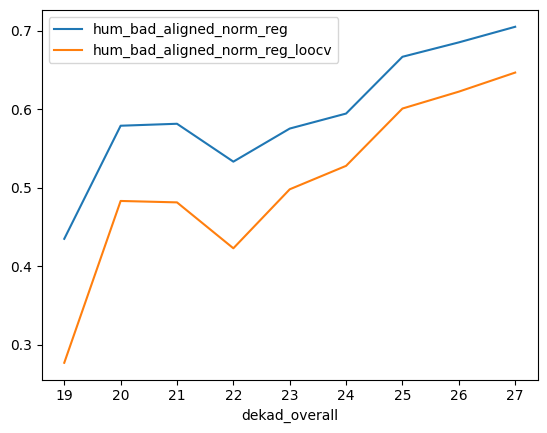

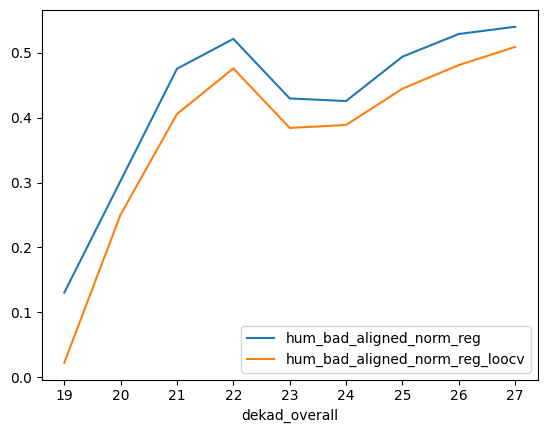

In [271]:
for target_col in ["hum_bad_aligned_norm", "cerf_aligned_norm"]:
    df_corr[df_corr["variable"] == target_col].set_index("dekad_overall")[
        ["hum_bad_aligned_norm_reg", "hum_bad_aligned_norm_reg_loocv"]
    ].plot()

In [350]:
reg_col = "hum_bad_aligned_norm_reg_loocv"

for single_nyears_target in range(1, total_years):
    print(single_nyears_target)
    # if single_nyears_target != 7:
    #     continue
    df_dek_compare["trigger_flat"] = df_dek_compare.groupby("dekad_overall")[
        reg_col
    ].transform(lambda x: x >= x.nlargest(single_nyears_target).min())

    dicts = []
    for dekad, group in df_dek_compare.groupby("dekad_overall"):
        pp = group["trigger_flat"]
        p = group["target"]
        tp = pp & p
        ppv = tp.sum() / pp.sum()
        dicts.append({"dekad": dekad, "ppv": ppv})

    df_ppv = pd.DataFrame(dicts)
    display(df_ppv)
    best_ppv = df_ppv["ppv"].max()

    dicts = []
    for dekad, group in df_dek_compare.groupby("dekad_overall"):
        nyears_thresh = single_nyears_target
        ppv = 0
        while ppv < best_ppv:
            group["trigger_revised"] = (
                group[reg_col] >= group[reg_col].nlargest(nyears_thresh).min()
            )
            pp = group["trigger_revised"]
            p = group["target"]
            tp = pp & p
            ppv = tp.sum() / pp.sum()
            nyears_thresh -= 1
            if nyears_thresh == 0:
                break
        dicts.append({"dekad": dekad, "n_years_thresh": nyears_thresh})

    df_threshs = pd.DataFrame(dicts)
    display(df_threshs)

1


,dekad,ppv
0,19,1.0
1,20,1.0
2,21,1.0
3,22,1.0
4,23,1.0
5,24,1.0
6,25,0.0
7,26,0.0
8,27,0.0


,dekad,n_years_thresh
0,19,0
1,20,0
2,21,0
3,22,0
4,23,0
5,24,0
6,25,0
7,26,0
8,27,0


2


,dekad,ppv
0,19,0.5
1,20,0.5
2,21,0.5
3,22,0.5
4,23,1.0
5,24,0.5
6,25,0.0
7,26,0.0
8,27,0.0


...

,dekad,ppv
0,19,0.25000
1,20,0.28125
2,21,0.28125
3,22,0.28125
4,23,0.28125
5,24,0.28125
6,25,0.28125
7,26,0.28125
8,27,0.28125


,dekad,n_years_thresh
0,19,23
1,20,31
2,21,31
3,22,31
4,23,31
5,24,31
6,25,31
7,26,31
8,27,31


33


,dekad,ppv
0,19,0.242424
1,20,0.272727
2,21,0.272727
3,22,0.272727
4,23,0.272727
5,24,0.272727
6,25,0.272727
7,26,0.272727
8,27,0.272727


,dekad,n_years_thresh
0,19,28
1,20,32
2,21,32
3,22,32
4,23,32
5,24,32
6,25,32
7,26,32
8,27,32


In [313]:
df_dek_compare["hum_bad_aligned_norm_reg_loocv"].nlargest(5).min()

np.float64(1.436950002172905)

In [314]:
dicts = []
for dekad, group in df_dek_compare.groupby("dekad_overall"):
    pp = group["trigger"]
    p = group["target"]
    tp = pp & p
    fp = pp & ~p
    ppv = tp.sum() / pp.sum()
    dicts.append({"dekad": dekad, "ppv": ppv})

In [315]:
df_ppv = pd.DataFrame(dicts)

In [316]:
df_ppv

,dekad,ppv
0,19,0.250
1,20,0.500
2,21,0.500
3,22,0.500
4,23,0.375
5,24,0.500
6,25,0.625
7,26,0.500
8,27,0.500


In [289]:
ppv

np.float64(0.4)